# Synthetic GMLC - Day-Ahead Renewable Generation

Applies the same perturbation model used for regional load in `synthetic_gmlc.ipynb`,
now to every **Hydro**, **PV**, **RTPV**, and **WIND** generator in
`data/GMLC_ts_data/`.

For generator $j$ at hour $t$:

$$g^j_t = \hat{g}^j_t + f^j_t \cdot \hat{g}^j_t = (1 + f^j_t)\,\hat{g}^j_t$$

$$f^j_t = \alpha f^j_{t-1} + \alpha \varepsilon^j_t, \qquad f^j_0 = 0, \qquad
\varepsilon^j_t \sim \mathcal{N}(0, 0.1), \qquad \alpha = 0.05$$

Every generator draws its own independent $f$ path. Two properties carry over from the
load case and matter here:

- $|f| \ll 1$, so $(1+f) > 0$ and the synthetic output is **never negative**.
- Because the perturbation is multiplicative, an hour with $\hat{g}^j_t = 0$ stays
  exactly $0$ - PV and RTPV keep their true overnight zeros rather than picking up
  spurious night-time generation.

## Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REPO = Path.cwd()
while not (REPO / "data").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
TS_DIR = REPO / "data" / "GMLC_ts_data"

# folder -> day-ahead file, in plot order
SOURCES = {
    "Hydro": TS_DIR / "Hydro" / "DAY_AHEAD_hydro.csv",
    "PV":    TS_DIR / "PV"    / "DAY_AHEAD_pv.csv",
    "RTPV":  TS_DIR / "RTPV"  / "DAY_AHEAD_rtpv.csv",
    "WIND":  TS_DIR / "WIND"  / "DAY_AHEAD_wind.csv",
}
# Okabe-Ito, colorblind-safe; source -> color is fixed for every figure below
COLORS = {"Hydro": "#0072B2", "PV": "#E69F00", "RTPV": "#CC79A7", "WIND": "#009E73"}

for name, path in SOURCES.items():
    print(f"{name:6s} {path.exists()}  {path}")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#888888",
    "font.size": 9,
})

Hydro  True  c:\Users\JKLCh\Desktop\ND_PhD\Research\GNN_PCM\data\GMLC_ts_data\Hydro\DAY_AHEAD_hydro.csv
PV     True  c:\Users\JKLCh\Desktop\ND_PhD\Research\GNN_PCM\data\GMLC_ts_data\PV\DAY_AHEAD_pv.csv
RTPV   True  c:\Users\JKLCh\Desktop\ND_PhD\Research\GNN_PCM\data\GMLC_ts_data\RTPV\DAY_AHEAD_rtpv.csv
WIND   True  c:\Users\JKLCh\Desktop\ND_PhD\Research\GNN_PCM\data\GMLC_ts_data\WIND\DAY_AHEAD_wind.csv


### Load the day-ahead profiles

`Year/Month/Day/Period` are turned into an hourly `DatetimeIndex` (`Period` is 1-based, so it maps to hour 0-23). Everything else in the file is a generator column.

In [3]:
def read_ts(path):
    """Read one GMLC day-ahead file -> DataFrame indexed by hour, one column per generator."""
    df = pd.read_csv(path)
    ts = (pd.to_datetime(dict(year=df.Year, month=df.Month, day=df.Day))
          + pd.to_timedelta(df.Period - 1, unit="h"))
    gens = [c for c in df.columns if c not in ("Year", "Month", "Day", "Period")]
    return df[gens].astype(float).set_axis(ts).sort_index().rename_axis("timestamp")

orig = {name: read_ts(path) for name, path in SOURCES.items()}

pd.DataFrame({
    "generators": {k: v.shape[1] for k, v in orig.items()},
    "hours": {k: v.shape[0] for k, v in orig.items()},
    "start": {k: v.index.min() for k, v in orig.items()},
    "end": {k: v.index.max() for k, v in orig.items()},
    "peak (MW)": {k: v.values.max().round(1) for k, v in orig.items()},
    "total energy (GWh)": {k: (v.values.sum() / 1e3).round(1) for k, v in orig.items()},
})

,generators,hours,start,end,peak (MW),total energy (GWh)
Hydro,20,8784,2020-01-01,2020-12-31 23:00:00,50.0,4082.1
PV,25,8784,2020-01-01,2020-12-31 23:00:00,176.3,3751.6
RTPV,31,8784,2020-01-01,2020-12-31 23:00:00,93.1,2147.8
WIND,4,8784,2020-01-01,2020-12-31 23:00:00,847.0,7149.4


## Generate the synthetic profiles

In [4]:
ALPHA = 0.05
EPS_STD = 0.1
SEED = 0

def simulate_f(n, alpha=ALPHA, eps_std=EPS_STD, rng=None):
    """f_t = alpha * f_{t-1} + alpha * eps_t,  f_0 = 0,  eps_t ~ N(0, eps_std)."""
    rng = np.random.default_rng() if rng is None else rng
    eps = rng.normal(0.0, eps_std, size=n)
    f = np.empty(n)
    prev = 0.0
    for t in range(n):
        prev = alpha * prev + alpha * eps[t]
        f[t] = prev
    return f

rng = np.random.default_rng(SEED)

f_paths, synth = {}, {}
for name, df in orig.items():
    f_paths[name] = pd.DataFrame(
        {g: simulate_f(len(df), rng=rng) for g in df.columns}, index=df.index)
    synth[name] = df + f_paths[name] * df          # g = ghat + f * ghat

# invariants the model is supposed to guarantee
for name in SOURCES:
    assert (synth[name].values >= 0).all(), f"{name}: negative synthetic output"
    zeros = orig[name].values == 0
    assert (synth[name].values[zeros] == 0).all(), f"{name}: zero hours were perturbed"
print("all sources: non-negative, and zero hours preserved")

pd.DataFrame({
    "f std": {k: v.values.std().round(5) for k, v in f_paths.items()},
    "f min": {k: v.values.min().round(5) for k, v in f_paths.items()},
    "f max": {k: v.values.max().round(5) for k, v in f_paths.items()},
    "orig energy (GWh)": {k: (orig[k].values.sum() / 1e3).round(2) for k in SOURCES},
    "synth energy (GWh)": {k: (synth[k].values.sum() / 1e3).round(2) for k in SOURCES},
    "synth min (MW)": {k: synth[k].values.min().round(3) for k in SOURCES},
    "synth peak (MW)": {k: synth[k].values.max().round(2) for k in SOURCES},
})

all sources: non-negative, and zero hours preserved


,f std,f min,f max,orig energy (GWh),synth energy (GWh),synth min (MW),synth peak (MW)
Hydro,0.00502,-0.02274,0.02339,4082.08,4082.09,0.198,50.68
PV,0.00501,-0.02181,0.02157,3751.62,3751.58,0.000,176.66
RTPV,0.00500,-0.02269,0.02241,2147.79,2147.80,0.000,93.56
WIND,0.00502,-0.02323,0.02228,7149.38,7148.73,0.000,855.51


## The coefficient process $f^j_t$\n\nOne representative generator per source (the first column), plus the pooled distribution of $f$ across all generators and hours.

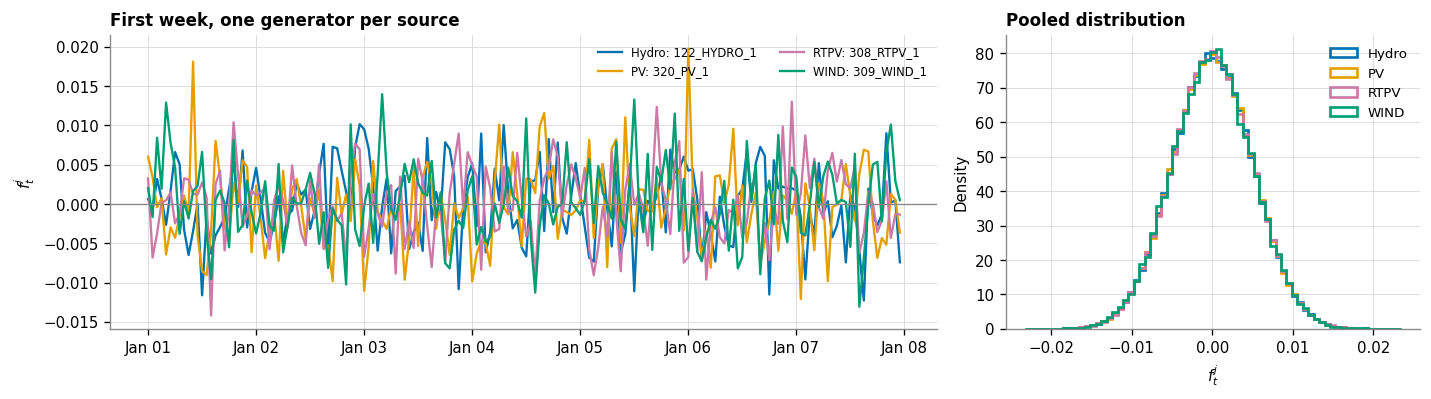

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4),
                         gridspec_kw={"width_ratios": [2, 1]})

for name in SOURCES:
    g = f_paths[name].columns[0]
    wk = f_paths[name][g].iloc[:24 * 7]
    axes[0].plot(wk.index, wk.values, color=COLORS[name], lw=1.4, label=f"{name}: {g}")
axes[0].axhline(0, color="#888888", lw=0.8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].set_ylabel(r"$f^j_t$")
axes[0].set_title("First week, one generator per source", loc="left",
                  fontsize=10, fontweight="bold")
axes[0].legend(frameon=False, ncol=2, fontsize=7)

allf = np.concatenate([v.values.ravel() for v in f_paths.values()])
bins = np.linspace(allf.min(), allf.max(), 70)
for name in SOURCES:
    axes[1].hist(f_paths[name].values.ravel(), bins=bins, histtype="step", lw=1.6,
                 density=True, color=COLORS[name], label=name)
axes[1].set_xlabel(r"$f^j_t$")
axes[1].set_ylabel("Density")
axes[1].set_title("Pooled distribution", loc="left", fontsize=10, fontweight="bold")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Fleet totals: synthetic vs. original

Hourly sum over all generators of each type, across the full year. The original is the pale band; the synthetic series is drawn thin on top.

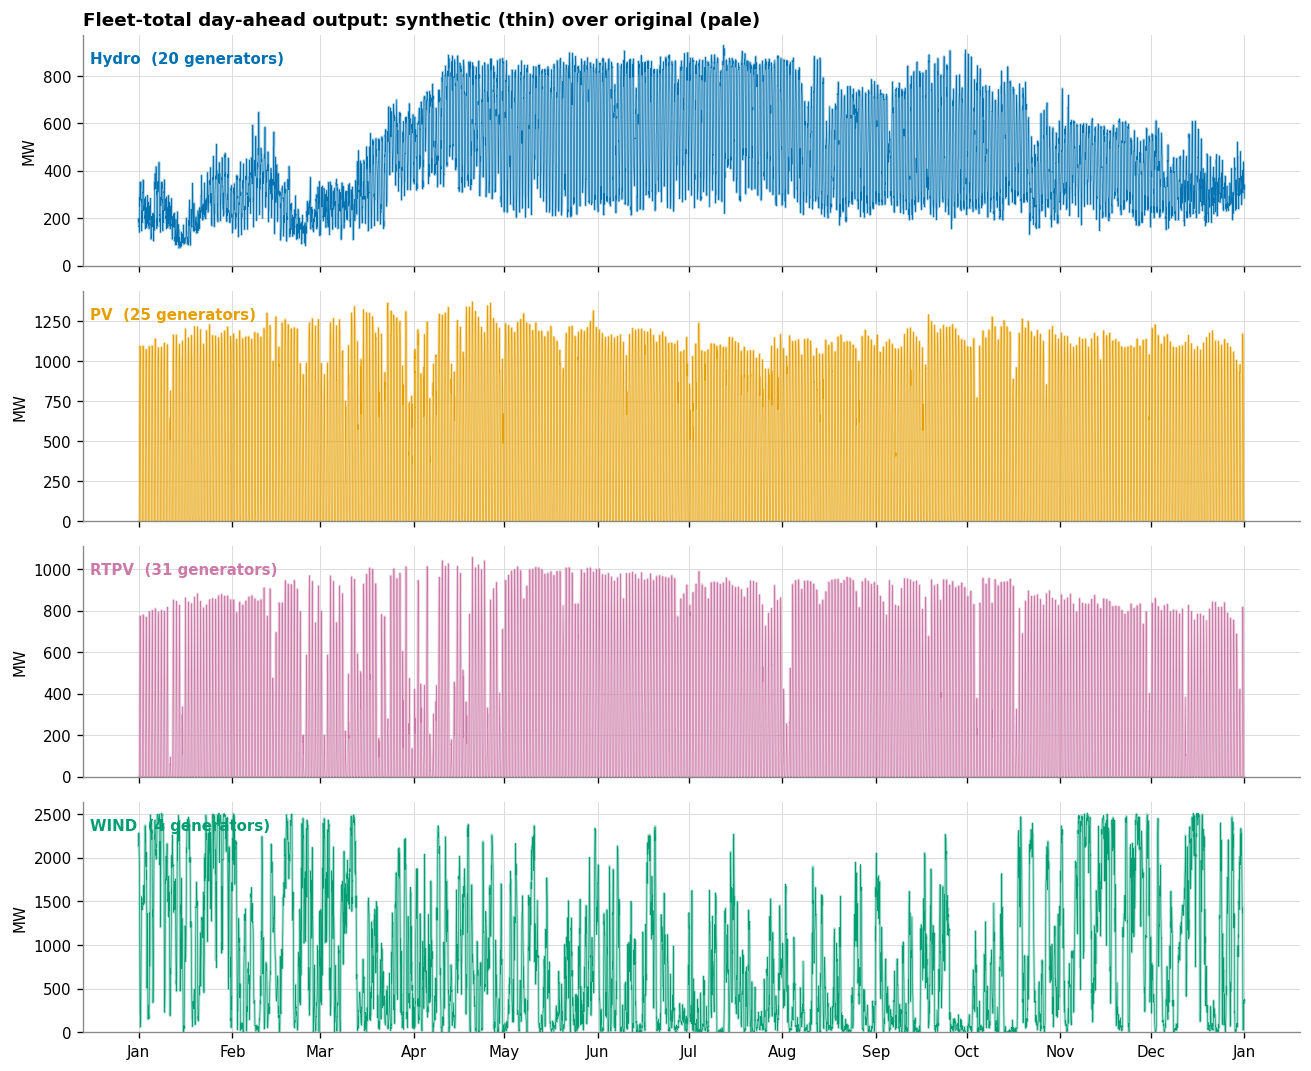

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for ax, name in zip(axes, SOURCES):
    o = orig[name].sum(axis=1)
    s = synth[name].sum(axis=1)
    ax.plot(o.index, o.values, color=COLORS[name], lw=1.6, alpha=0.30)
    ax.plot(s.index, s.values, color=COLORS[name], lw=0.4)
    ax.set_ylabel("MW")
    ax.set_ylim(bottom=0)
    ax.text(0.005, 0.93, f"{name}  ({orig[name].shape[1]} generators)",
            transform=ax.transAxes, color=COLORS[name], fontweight="bold", va="top")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].set_title("Fleet-total day-ahead output: synthetic (thin) over original (pale)",
                  loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

### First week, fleet totals

Same quantity zoomed in, where the two series can actually be told apart.

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 9), sharex="col",
                         gridspec_kw={"width_ratios": [2, 1]})
for row, name in enumerate(SOURCES):
    o = orig[name].sum(axis=1).iloc[:24 * 7]
    s = synth[name].sum(axis=1).iloc[:24 * 7]

    ax = axes[row, 0]
    ax.plot(o.index, o.values, color=COLORS[name], lw=3.0, alpha=0.28)
    ax.plot(s.index, s.values, color=COLORS[name], lw=1.2)
    ax.set_ylabel("MW")
    ax.set_ylim(bottom=0)
    ax.text(0.005, 0.93, name, transform=ax.transAxes, color=COLORS[name],
            fontweight="bold", va="top")

    ax = axes[row, 1]
    ax.plot(o.index, (s - o).values, color=COLORS[name], lw=1.2)
    ax.axhline(0, color="#888888", lw=0.8)
    ax.set_ylabel("MW")

for ax in axes[-1]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0, 0].set_title("Synthetic (thin) over original (pale)", loc="left",
                     fontsize=10, fontweight="bold")
axes[0, 1].set_title(r"Perturbation  $f^j_t \hat{g}^j_t$ (fleet sum)", loc="left",
                     fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

## Individual generators

One sampled generator per source, over the first week. Note that PV and RTPV return to exactly zero overnight in the synthetic series as well.

In [ ]:
SAMPLE = {name: orig[name].sum().idxmax() for name in SOURCES}   # largest producer
print("sampled generators:", SAMPLE)

fig, axes = plt.subplots(2, 2, figsize=(12, 5.5))
for ax, name in zip(axes.ravel(), SOURCES):
    g = SAMPLE[name]
    o = orig[name][g].iloc[:24 * 7]
    s = synth[name][g].iloc[:24 * 7]
    ax.plot(o.index, o.values, color=COLORS[name], lw=3.0, alpha=0.28, label="original")
    ax.plot(s.index, s.values, color=COLORS[name], lw=1.2, label="synthetic")
    ax.axhline(0, color="#888888", lw=0.8)
    ax.set_ylim(bottom=0)
    ax.set_ylabel("MW")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.set_title(f"{name}: {g}", loc="left", fontsize=10, fontweight="bold",
                 color=COLORS[name])
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

### Average daily shape

Fleet-total output averaged by hour of day, original vs. synthetic.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, name in zip(axes, SOURCES):
    o = orig[name].sum(axis=1)
    s = synth[name].sum(axis=1)
    ax.plot(o.groupby(o.index.hour).mean(), color=COLORS[name], lw=3.0, alpha=0.28,
            label="original")
    ax.plot(s.groupby(s.index.hour).mean(), color=COLORS[name], lw=1.6,
            label="synthetic")
    ax.set_xlabel("Hour of day")
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_ylim(bottom=0)
    ax.set_title(name, fontsize=10, fontweight="bold", color=COLORS[name])
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Mean fleet output (MW)")
fig.suptitle("Average daily shape, fleet totals", x=0.005, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

### Duration curves

Fleet-total output sorted high to low. The synthetic curve tracks the original; the y-axis is pinned at zero to make the non-negativity visible.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, name in zip(axes, SOURCES):
    o = np.sort(orig[name].sum(axis=1).values)[::-1]
    s = np.sort(synth[name].sum(axis=1).values)[::-1]
    pct = np.linspace(0, 100, len(o))
    ax.plot(pct, o, color=COLORS[name], lw=3.0, alpha=0.28, label="original")
    ax.plot(pct, s, color=COLORS[name], lw=1.6, label="synthetic")
    ax.axhline(0, color="#888888", lw=0.8)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Percent of hours (%)")
    ax.set_title(name, fontsize=10, fontweight="bold", color=COLORS[name])
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Fleet output (MW)")
fig.suptitle("Duration curves, fleet totals", x=0.005, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

## Per-generator summary

In [ ]:
rows = []
for name in SOURCES:
    for g in orig[name].columns:
        o, s = orig[name][g], synth[name][g]
        rows.append({
            "source": name,
            "generator": g,
            "orig energy (GWh)": o.sum() / 1e3,
            "synth energy (GWh)": s.sum() / 1e3,
            "orig peak (MW)": o.max(),
            "synth peak (MW)": s.max(),
            "synth min (MW)": s.min(),
            "perturbation std (MW)": (s - o).std(),
            "mean abs dev (%)": 100 * ((s - o).abs().sum() / o.sum()) if o.sum() else 0.0,
        })
gen_summary = pd.DataFrame(rows).set_index(["source", "generator"]).round(4)
print(f"{len(gen_summary)} generators total")
gen_summary

## Writing the synthetic files (optional)

Set `SAVE = True` to write one CSV per source next to the original, in the same
`Year, Month, Day, Period, <generators...>` layout the GMLC files use. Nothing is
written while `SAVE` is `False`, and the originals are never overwritten - output
goes to `DAY_AHEAD_<source>_synthetic.csv`.

In [ ]:
SAVE = False

OUT_NAMES = {"Hydro": "DAY_AHEAD_hydro_synthetic.csv",
             "PV": "DAY_AHEAD_pv_synthetic.csv",
             "RTPV": "DAY_AHEAD_rtpv_synthetic.csv",
             "WIND": "DAY_AHEAD_wind_synthetic.csv"}

def to_gmlc_frame(df):
    """Inverse of read_ts: DatetimeIndex -> Year/Month/Day/Period columns."""
    out = df.copy()
    idx = out.index
    out.insert(0, "Period", idx.hour + 1)
    out.insert(0, "Day", idx.day)
    out.insert(0, "Month", idx.month)
    out.insert(0, "Year", idx.year)
    return out.reset_index(drop=True)

for name, df in synth.items():
    dest = SOURCES[name].parent / OUT_NAMES[name]
    if SAVE:
        to_gmlc_frame(df).to_csv(dest, index=False)
        print("wrote", dest)
    else:
        print("would write", dest)